In [1]:
from IPython.display import Javascript
Javascript("""
function ClickConnect(){
console.log("Working");
document.querySelector("colab-connect-button").click()
}
setInterval(ClickConnect,60000)
""")

<IPython.core.display.Javascript object>

In [2]:
#My Project

In [3]:
!pip install datasets imbalanced-learn nltk tensorflow seaborn

In [4]:
!pip install tqdm

In [5]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from imblearn.under_sampling import RandomUnderSampler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

**Dataset**

In [6]:
from datasets import load_dataset

# Load the whole dataset
dataset = load_dataset('PKU-Alignment/BeaverTails')


# Load the training dataset
train_dataset = load_dataset('PKU-Alignment/BeaverTails', split='330k_train')
test_dataset = load_dataset('PKU-Alignment/BeaverTails', split='330k_test')

train_df = train_dataset.to_pandas()
test_df = test_dataset.to_pandas()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

round0/330k/train.jsonl.xz:   0%|          | 0.00/31.1M [00:00<?, ?B/s]

round0/330k/test.jsonl.xz:   0%|          | 0.00/2.44M [00:00<?, ?B/s]

round0/30k/train.jsonl.gz:   0%|          | 0.00/4.95M [00:00<?, ?B/s]

...

Generating 330k_train split:   0%|          | 0/300567 [00:00<?, ? examples/s]

Generating 330k_test split:   0%|          | 0/33396 [00:00<?, ? examples/s]

Generating 30k_train split:   0%|          | 0/27186 [00:00<?, ? examples/s]

Generating 30k_test split:   0%|          | 0/3021 [00:00<?, ? examples/s]

Train shape: (300567, 4)
Test shape: (33396, 4)


Create Multi-Class Labels

In [7]:
def assign_multi_class_label(row):

    if row['is_safe']:
        return 3

    elif row['category']['violence,aiding_and_abetting,incitement']:
        return 0

    elif row['category']['non_violent_unethical_behavior']:
        return 1

    elif (
        row['category']['misinformation_regarding_ethics,laws_and_safety']
        or row['category']['child_abuse']
        or row['category']['sexually_explicit,adult_content']
        or row['category']['privacy_violation']
        or row['category']['discrimination,stereotype,injustice']
    ):
        return 2

    else:
        return 3

In [8]:
train_df["label"] = train_df.apply(assign_multi_class_label, axis=1)
test_df["label"] = test_df.apply(assign_multi_class_label, axis=1)

In [9]:
print("Train distribution:")
print(train_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())

Train distribution:
label
3    148432
0     79544
1     53207
2     19384
Name: count, dtype: int64

Test distribution:
label
3    16242
0     9045
1     5929
2     2180
Name: count, dtype: int64


In [10]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove punctuation

    tokens = text.split()

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

def clean_for_lstm(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    return text

In [11]:
train_df["clean_prompt"] = train_df["prompt"].apply(clean_text)
test_df["clean_prompt"] = test_df["prompt"].apply(clean_text)

In [12]:
train_df["lstm_text"] = train_df["prompt"].apply(clean_for_lstm)
test_df["lstm_text"] = test_df["prompt"].apply(clean_for_lstm)

ML models

In [13]:
X_train = train_df["clean_prompt"]
y_train = train_df["label"]

X_test = test_df["clean_prompt"]
y_test = test_df["label"]

LSTM

In [14]:
X_train_lstm = train_df["lstm_text"]
X_test_lstm = test_df["lstm_text"]

In [15]:
rus = RandomUnderSampler(random_state=42)

X_resampled, y_resampled = rus.fit_resample(
    X_train.to_frame(),
    y_train
)

X_resampled = X_resampled["clean_prompt"]

print("Balanced class distribution:")
print(pd.Series(y_resampled).value_counts())

Balanced class distribution:
label
0    19384
1    19384
2    19384
3    19384
Name: count, dtype: int64


In [16]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

In [17]:
logistic_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000)),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

logistic_model.fit(X_train_final, y_train_final)

log_pred = logistic_model.predict(X_test)
log_probs = logistic_model.predict_proba(X_test)

In [18]:
print("Logistic Regression")
print(classification_report(y_test, log_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.70      0.82      0.75      9045
           1       0.55      0.66      0.60      5929
           2       0.38      0.68      0.49      2180
           3       0.81      0.59      0.68     16242

    accuracy                           0.67     33396
   macro avg       0.61      0.69      0.63     33396
weighted avg       0.71      0.67      0.67     33396



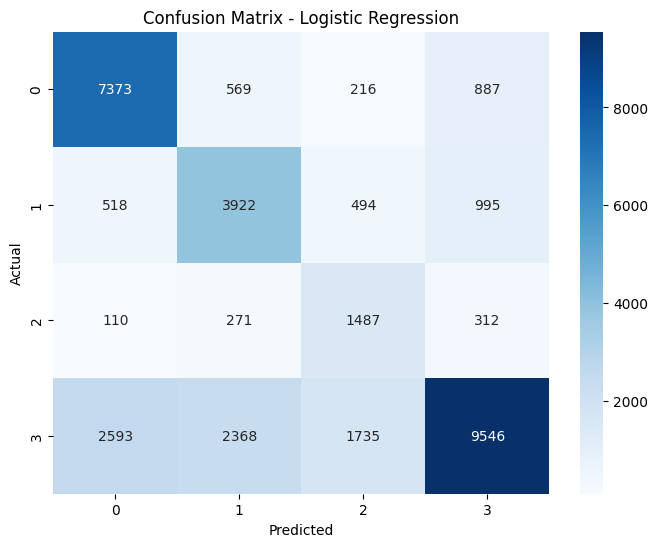

In [19]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

SVC

In [20]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

svc_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000)),
    ("model", LinearSVC(class_weight="balanced"))
])

svc_model.fit(X_train_final, y_train_final)

svc_pred = svc_model.predict(X_test)
svc_scores = svc_model.decision_function(X_test)

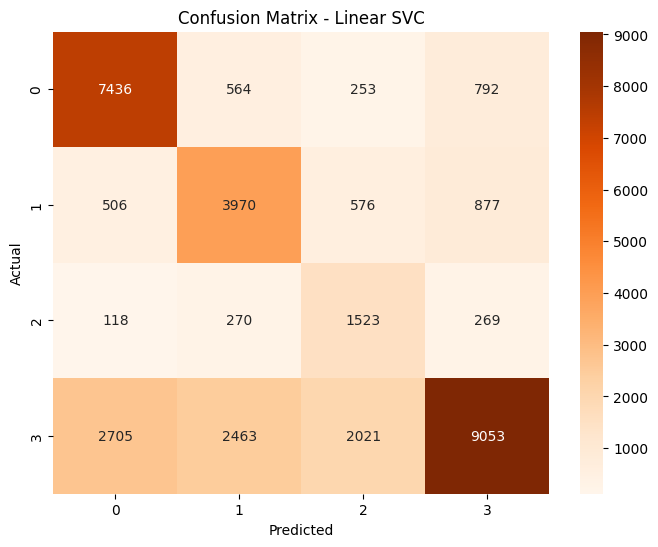

In [21]:
cm_svc = confusion_matrix(y_test, svc_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_svc, annot=True, fmt="d", cmap="Oranges")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVC")

plt.show()

In [22]:
!pip install tensorflow

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

In [24]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [25]:
max_words = 20000
max_length = 100

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X_train_lstm)

X_train_seq = tokenizer.texts_to_sequences(X_train_lstm)
X_test_seq = tokenizer.texts_to_sequences(X_test_lstm)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

In [26]:
label_encoder = LabelEncoder()

y_train_lstm = label_encoder.fit_transform(train_df["label"])
y_test_lstm = label_encoder.transform(test_df["label"])

In [27]:
model = Sequential([

    Embedding(input_dim=max_words, output_dim=128, input_length=max_length),

    LSTM(128, return_sequences=False),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(4, activation='softmax')  # 4 classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [28]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tqdm.keras import TqdmCallback

In [30]:
history = model.fit(
    X_train_pad,
    y_train_lstm,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[TqdmCallback(verbose=1)]
)

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/5
3758/3758 ━━━━━━━━━━━━━━━━━━━━ 943s 249ms/step - accuracy: 0.7392 - loss: 0.6892 - val_accuracy: 0.7680 - val_loss: 0.6241
Epoch 2/5
3758/3758 ━━━━━━━━━━━━━━━━━━━━ 927s 247ms/step - accuracy: 0.7756 - loss: 0.5906 - val_accuracy: 0.7732 - val_loss: 0.6040
Epoch 3/5
3758/3758 ━━━━━━━━━━━━━━━━━━━━ 895s 238ms/step - accuracy: 0.7825 - loss: 0.5627 - val_accuracy: 0.7775 - val_loss: 0.5921
Epoch 4/5
3758/3758 ━━━━━━━━━━━━━━━━━━━━ 890s 237ms/step - accuracy: 0.7880 - loss: 0.5466 - val_accuracy: 0.7814 - val_loss: 0.5911
Epoch 5/5
3758/3758 ━━━━━━━━━━━━━━━━━━━━ 889s 237ms/step - accuracy: 0.7905 - loss: 0.5351 - val_accuracy: 0.7821 - val_loss: 0.5937


In [31]:
lstm_probs = model.predict(X_test_pad)
lstm_pred = np.argmax(lstm_probs, axis=1)

1044/1044 ━━━━━━━━━━━━━━━━━━━━ 48s 46ms/step


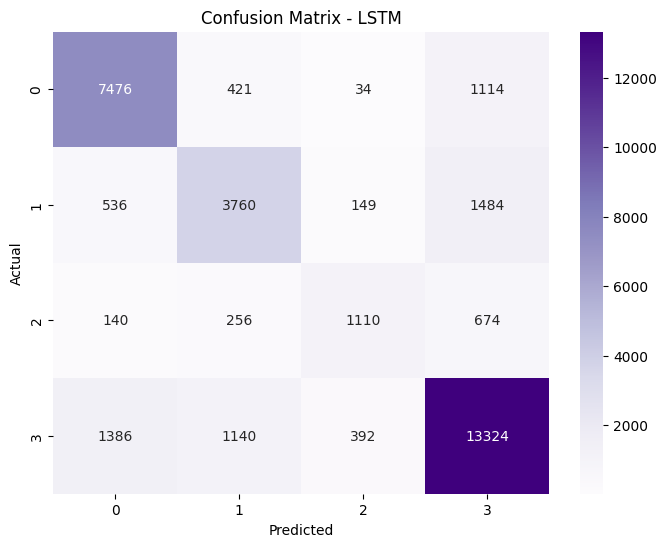

In [32]:
cm_lstm = confusion_matrix(y_test_lstm, lstm_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Purples")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LSTM")

plt.show()

In [33]:
print("Logistic Regression")
print(classification_report(y_test, log_pred))

print("SVC")
print(classification_report(y_test, svc_pred))

print("LSTM")
print(classification_report(y_test_lstm, lstm_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.70      0.82      0.75      9045
           1       0.55      0.66      0.60      5929
           2       0.38      0.68      0.49      2180
           3       0.81      0.59      0.68     16242

    accuracy                           0.67     33396
   macro avg       0.61      0.69      0.63     33396
weighted avg       0.71      0.67      0.67     33396

SVC
              precision    recall  f1-score   support

           0       0.69      0.82      0.75      9045
           1       0.55      0.67      0.60      5929
           2       0.35      0.70      0.46      2180
           3       0.82      0.56      0.66     16242

    accuracy                           0.66     33396
   macro avg       0.60      0.69      0.62     33396
weighted avg       0.71      0.66      0.66     33396

LSTM
              precision    recall  f1-score   support

           0       0.78      0.83      0.80   

In [34]:
classes = [0,1,2,3]

y_test_bin = label_binarize(y_test, classes=classes)

log_auc = roc_auc_score(y_test_bin, log_probs, multi_class="ovr")
svc_auc = roc_auc_score(y_test_bin, svc_scores, multi_class="ovr")
lstm_auc = roc_auc_score(y_test_bin, lstm_probs, multi_class="ovr")

print("Logistic AUC:", log_auc)
print("SVC AUC:", svc_auc)
print("LSTM AUC:", lstm_auc)

Logistic AUC: 0.8745295034934821
SVC AUC: 0.873660622823286
LSTM AUC: 0.9084879818311844


In [37]:
from sklearn.metrics import roc_auc_score, roc_curve

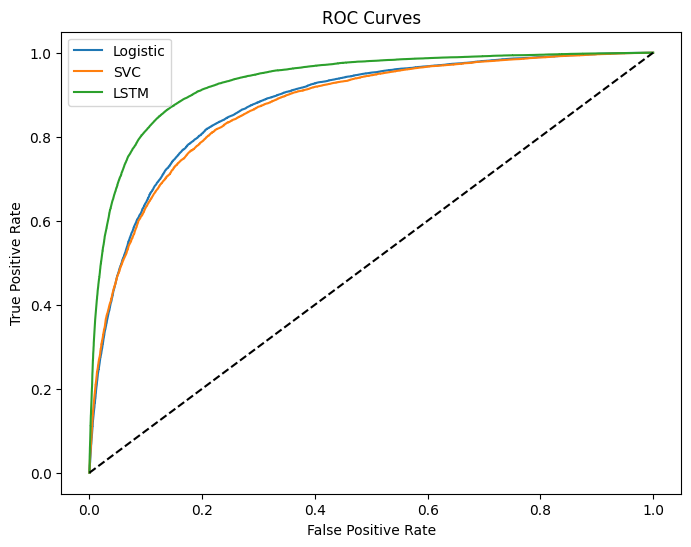

In [38]:
plt.figure(figsize=(8,6))

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), log_probs.ravel())
plt.plot(fpr, tpr, label="Logistic")

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), svc_scores.ravel())
plt.plot(fpr, tpr, label="SVC")

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), lstm_probs.ravel())
plt.plot(fpr, tpr, label="LSTM")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

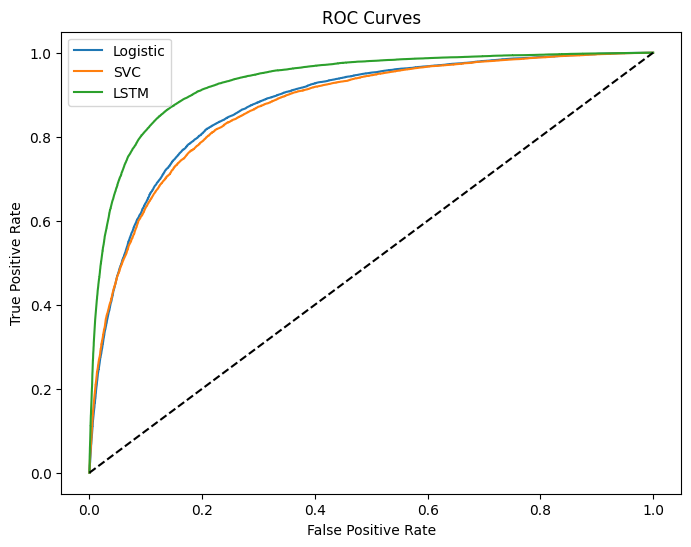

In [39]:
plt.figure(figsize=(8,6))

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), log_probs.ravel())
plt.plot(fpr, tpr, label="Logistic")

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), svc_scores.ravel())
plt.plot(fpr, tpr, label="SVC")

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), lstm_probs.ravel())
plt.plot(fpr, tpr, label="LSTM")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

In [42]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "SVC",
        "LSTM"
    ],

    "ROC-AUC":[
        log_auc,
        svc_auc,
        lstm_auc
    ]
})

results

,Model,ROC-AUC
0,Logistic Regression,0.874530
1,SVC,0.873661
2,LSTM,0.908488


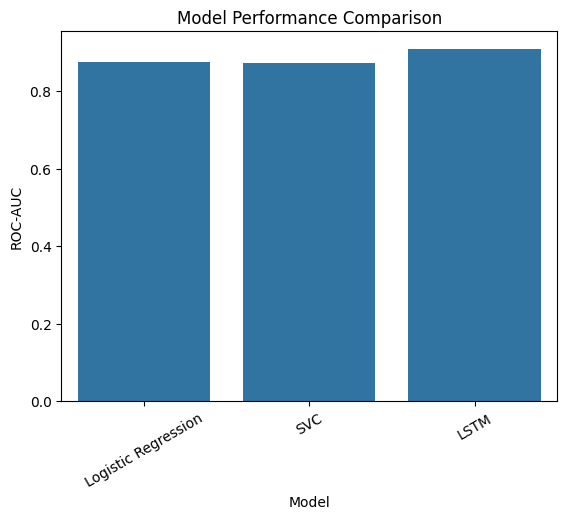

In [43]:
sns.barplot(
    x="Model",
    y="ROC-AUC",
    data=results
)

plt.title("Model Performance Comparison")
plt.xticks(rotation=30)

plt.show()